<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/module2_unsupervised_segmentation_practice_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Unsupervised Segmentation**
This is a method where an image is divided into meaningful regions without using labeled data since it is unsupervised.We group pixels in an image based on similarity,without telling algorithm what objects are in the image.Since this is unsupervised the algorithm learns pattern by itself.
**Clustering Algorithm**
This is a a group of data into clusters based on similtarity,withpud using labels.For example one group could be students with similiar grades,or pixels with similiar colors.

K-means is one of the most used clustering algorithm used to group data into K clusters based on similtarity.This method works in this form,we choose a number k which is the number of groups we want and this algorithm separates data into K clusters.After deciding how many cluster we want,we have to initiazile centroids after that the algorithm randomly picks k points as starting center,each pixel is assigned to the closest centroid based on the distance usally Euclidean distance.After grouping we have to update centroids and compute a new center of each cluster.This is repeated until cluster stop changing and centroids stabilize.The number of centroids is the number of K which we choose by ourself.

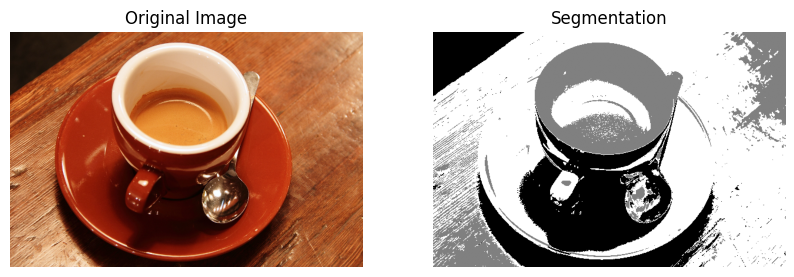

In [8]:
import skimage as sk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
import numpy as np
image = sk.data.coffee()
value_image = np.reshape(image,(image.shape[0]*image.shape[1],image.shape[2]))
k=3
kmeans=KMeans(n_clusters=k,random_state=0).fit(value_image)
v_kmeans=kmeans.predict(value_image)
image_kmeans=np.reshape(v_kmeans,(image.shape[0],image.shape[1]))
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Original Image')
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(image_kmeans, cmap=plt.cm.gray)
ax2.set_title('Segmentation')
ax2.set_axis_off()

plt.show()


**Gaussian Mixture Models**

This is a probabilistic clustering algorithm used for groupind data its like K-means but more flexible.This works in this form instead of assigning each point to a single cluster like before GMM assumes that data comes from mixture of several Gaussian distribution.In this method each point belongs to all clusters with probabiliteies and clusters can be different shapes and sizes.Now for each cluster we have to intialize mean,covariance and weight,after that for each data point we have to cmpute probability of belonging to each Gaussian,after that we have to update means,covariance and weight based on probabilities.This step repeates until it covergence.

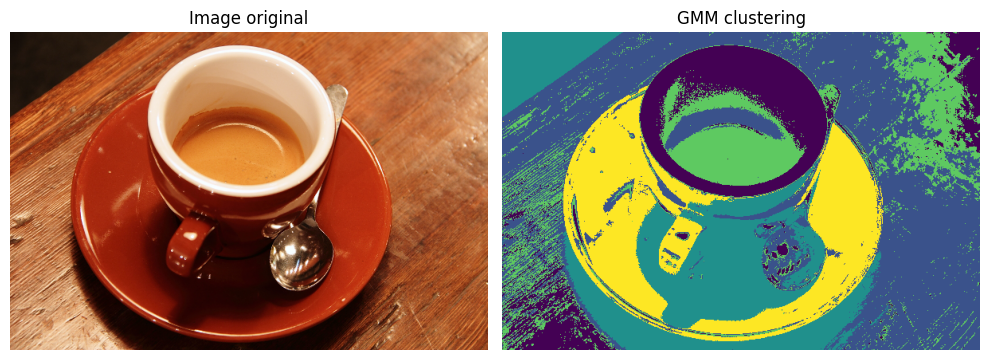

In [12]:
import skimage as sk
import numpy as np
from sklearn import mixture
import matplotlib.pyplot as plt
from matplotlib import gridspec
gmm = mixture.GaussianMixture(n_components=5).fit(value_image)
v_gmm = gmm.fit_predict(value_image)
I_gmm = np.reshape(v_gmm,(image.shape[0],image.shape[1]))
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2)
ax0 = fig.add_subplot(gs[0,0])
ax0.imshow(image)
ax0.set_title('Image original')
ax0.set_axis_off()
ax1 = fig.add_subplot(gs[0,1])
ax1.imshow(I_gmm)
ax1.set_title('GMM clustering')
ax1.set_axis_off()
plt.tight_layout()
plt.show()

Unlike K-means where you choose K manually,in GMM we often estimate the best number of clusters using a model selection method and the most common method is Bayesian Information Criterion(BIC).This helps us to know if the number of efficent.If the model fits better BIC decreses and if the model becomes too xomplex BIC increases,so we choose the model with lowest BIC.

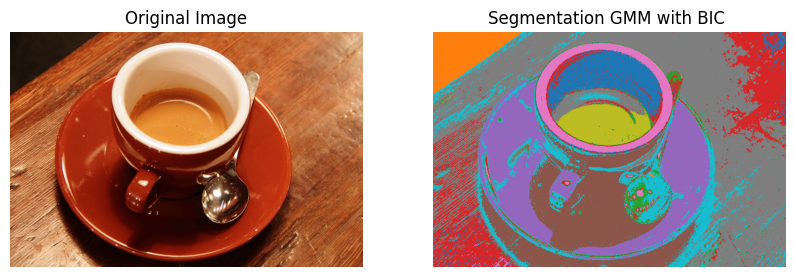

In [14]:
from sklearn.datasets import make_blobs
import numpy as np
from sklearn import mixture
NMAX = 10
bic = []
for kG in np.arange(1,NMAX+1):
    gmm = mixture.GaussianMixture(n_components=kG,covariance_type='full').fit(value_image)
    bic.append(gmm.bic(value_image))

idx_winner = np.argmin(bic)
gmm_win = mixture.GaussianMixture(n_components=idx_winner+1,covariance_type='full').fit(value_image)
v_gmm = gmm_win.fit_predict(value_image)
I_gmm_bic = np.reshape(v_gmm,(image.shape[0],image.shape[1]))

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Original Image')
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(I_gmm_bic, cmap=plt.cm.tab10)
ax2.set_title('Segmentation GMM with BIC '.format(k))
ax2.set_axis_off()

plt.show()